# 05 TF-IDF Logistic Regression with A/B Swap Augmentation

This notebook evaluates whether A/B swap augmentation can reduce position bias for the TF-IDF Logistic Regression baseline. The validation set is kept in the original, non-augmented order.

## 1. Imports and Path Setup

Set up libraries, project paths, constants, and output folders.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
LABELS = [0, 1, 2]
LABEL_NAME_MAP = {0: 'A_win', 1: 'B_win', 2: 'tie'}
TARGET_NAMES = [LABEL_NAME_MAP[label] for label in LABELS]

current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

processed_data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'outputs' / 'figures'
logs_dir = project_root / 'outputs' / 'logs'
models_dir = project_root / 'outputs' / 'models'
oof_dir = project_root / 'outputs' / 'oof'
submissions_dir = project_root / 'outputs' / 'submissions'

for output_dir in [figures_dir, logs_dir, models_dir, oof_dir, submissions_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

train_path = processed_data_dir / 'train_eda.csv'
test_path = processed_data_dir / 'test_eda.csv'

print(f'Project root: {project_root}')
print(f'train_eda.csv exists: {train_path.exists()} -> {train_path}')
print(f'test_eda.csv exists: {test_path.exists()} -> {test_path}')

Project root: D:\LLM_Classification_finetuning
train_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\train_eda.csv
test_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\test_eda.csv


## 2. Read Processed Data

Load the processed EDA data. Raw Kaggle files are not used.

In [2]:
train = pd.read_csv(train_path, encoding='utf-8-sig')
test = pd.read_csv(test_path, encoding='utf-8-sig')

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

print('\ntrain columns:')
print(train.columns.tolist())

print('\ntest columns:')
print(test.columns.tolist())

display(train.head(3))
display(test.head(3))

train shape: (57477, 20)
test shape: (3, 12)

train columns:
['id', 'model_a', 'model_b', 'winner_model_a', 'winner_model_b', 'winner_tie', 'label_sum', 'label', 'label_name', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']

test columns:
['id', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']


,id,model_a,model_b,winner_model_a,winner_model_b,winner_tie,label_sum,label,label_name,prompt_clean,response_a_clean,response_b_clean,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,30192,gpt-4-1106-preview,gpt-4-0613,1,0,0,1,0,A_win,"Is it morally right to try to have a certain percentage of females on managerial positions?\nOK, does pineapple belong on a pizza? Relax and give me fun ans...",The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves cons...,"As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and...",159,4459,1200,3259,29,674,205,469
1,53567,koala-13b,gpt-4-0613,0,1,0,1,1,B_win,What is the difference between marriage license and marriage certificate?\nHow can I get both of them as quick as possible in California \nWhat is the minim...,"A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, such as a county clerk's office or a state ...",A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1. Marriage License: A marriage license is a...,192,3096,3592,-496,36,539,579,-40
2,65089,gpt-3.5-turbo-0613,mistral-medium,0,0,1,1,2,tie,explain function calling. how would you call a function?,"Function calling is the process of invoking or executing a function in a programming language. To call a function, you need to use the function's name follo...",Function calling is the process of invoking a function in a program. A function is a block of code that performs a specific task and can be reused multiple ...,56,884,1796,-912,9,147,297,-150


,id,prompt_clean,response_a_clean,response_b_clean,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,136060,"I have three oranges today, I ate an orange yesterday. How many oranges do I have?",You have two oranges today.,You still have three oranges. Eating an orange yesterday does not affect the number of oranges you have today.,82,27,110,-83,16,5,19,-14
1,211333,"You are a mediator in a heated political debate between two opposing parties. Mr Reddy is very hung up on semantic definitions of sex and gender, and believ...","Thank you for sharing the details of the situation. As a mediator, I understand the importance of finding a middle ground that both parties can agree upon.\...","Mr Reddy and Ms Blue both have valid points in their arguments. On one hand, Mr Reddy is correct that women are adult human females, as defined by their bio...",484,1445,456,989,84,221,75,146
2,1233961,"How to initialize the classification head when I do transfer learning. For example, I have a pre-trained vision transformer on ImageNet, and now I want to f...","When you want to initialize the classification head for transfer learning, you can follow these steps:\n\n 1. Load the pre-trained model: First, load the p...","To initialize the classification head when performing transfer learning, follow these steps:\n\n1. Load the pre-trained vision transformer model that was tr...",211,3961,3648,313,36,626,481,145


## 3. Column Check

Validate the columns needed for text construction, labels, swap augmentation, and saved outputs.

In [3]:
required_train_columns = {
    'id',
    'label',
    'label_name',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
}

required_test_columns = {
    'id',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
}

missing_train_columns = sorted(required_train_columns - set(train.columns))
missing_test_columns = sorted(required_test_columns - set(test.columns))

if missing_train_columns:
    raise ValueError(f'train_eda.csv missing columns: {missing_train_columns}')

if missing_test_columns:
    raise ValueError(f'test_eda.csv missing columns: {missing_test_columns}')

train['label'] = train['label'].astype(int)

print('Column check passed.')
print('\nLabel counts:')
display(train['label_name'].value_counts().reindex(TARGET_NAMES))

Column check passed.

Label counts:


label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64

## 4. Train Validation Split Before Augmentation

Split the original processed train data first. Only the training split will be augmented; the validation split remains unchanged.

In [4]:
train_split, valid_split = train_test_split(
    train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train['label'],
)

train_split = train_split.reset_index(drop=True)
valid_split = valid_split.reset_index(drop=True)

print(f'train_split shape: {train_split.shape}')
print(f'valid_split shape: {valid_split.shape}')

print('\nTrain split label counts:')
display(train_split['label_name'].value_counts().reindex(TARGET_NAMES))

print('\nValid split label counts:')
display(valid_split['label_name'].value_counts().reindex(TARGET_NAMES))

train_split shape: (45981, 20)
valid_split shape: (11496, 20)

Train split label counts:


label_name
A_win    16051
B_win    15721
tie      14209
Name: count, dtype: int64


Valid split label counts:


label_name
A_win    4013
B_win    3931
tie      3552
Name: count, dtype: int64

## 5. A/B Swap Augmentation on Training Split Only

Create a swapped copy of the training split by exchanging response A and response B. A-win and B-win labels are flipped, while tie remains tie.

In [5]:
def swap_ab_dataframe(df):
    swapped = df.copy()

    swapped['response_a_clean'] = df['response_b_clean'].values
    swapped['response_b_clean'] = df['response_a_clean'].values

    if {'response_a_char_len', 'response_b_char_len'}.issubset(swapped.columns):
        swapped['response_a_char_len'] = df['response_b_char_len'].values
        swapped['response_b_char_len'] = df['response_a_char_len'].values

    if 'response_len_diff' in swapped.columns:
        swapped['response_len_diff'] = swapped['response_a_char_len'] - swapped['response_b_char_len']

    if {'response_a_word_len', 'response_b_word_len'}.issubset(swapped.columns):
        swapped['response_a_word_len'] = df['response_b_word_len'].values
        swapped['response_b_word_len'] = df['response_a_word_len'].values

    if 'response_word_len_diff' in swapped.columns:
        swapped['response_word_len_diff'] = swapped['response_a_word_len'] - swapped['response_b_word_len']

    if 'label' in swapped.columns:
        swapped['label'] = df['label'].map({0: 1, 1: 0, 2: 2}).astype(int).values
        swapped['label_name'] = swapped['label'].map(LABEL_NAME_MAP)
    swapped['is_swapped_aug'] = 1
    return swapped


train_split = train_split.copy()
train_split['is_swapped_aug'] = 0
swapped_train = swap_ab_dataframe(train_split)
train_aug = pd.concat([train_split, swapped_train], ignore_index=True)
train_aug = train_aug.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Original training size: {len(train_split)}')
print(f'Swapped training size: {len(swapped_train)}')
print(f'Augmented training size: {len(train_aug)}')

print('\nOriginal training label counts:')
display(train_split['label_name'].value_counts().reindex(TARGET_NAMES))

print('\nSwapped training label counts:')
display(swapped_train['label_name'].value_counts().reindex(TARGET_NAMES))

print('\nAugmented training label counts:')
display(train_aug['label_name'].value_counts().reindex(TARGET_NAMES))

Original training size: 45981
Swapped training size: 45981
Augmented training size: 91962

Original training label counts:


label_name
A_win    16051
B_win    15721
tie      14209
Name: count, dtype: int64


Swapped training label counts:


label_name
A_win    15721
B_win    16051
tie      14209
Name: count, dtype: int64


Augmented training label counts:


label_name
A_win    31772
B_win    31772
tie      28418
Name: count, dtype: int64

## 6. Build Text Input

Build the TF-IDF input text for augmented training data, original validation data, and test data.

In [6]:
def build_text_input(df):
    prompt = df['prompt_clean'].fillna('').astype(str)
    response_a = df['response_a_clean'].fillna('').astype(str)
    response_b = df['response_b_clean'].fillna('').astype(str)

    return (
        'Prompt:\n' + prompt
        + '\n\nResponse A:\n' + response_a
        + '\n\nResponse B:\n' + response_b
    )


train_aug['text_input'] = build_text_input(train_aug)
valid_split['text_input'] = build_text_input(valid_split)
test['text_input'] = build_text_input(test)

X_train = train_aug['text_input']
y_train = train_aug['label'].astype(int)
X_valid = valid_split['text_input']
y_valid = valid_split['label'].astype(int)

print('Text input created.')
print(f'X_train size: {len(X_train)}')
print(f'X_valid size: {len(X_valid)}')

print('\nExample text_input:')
print(train_aug.loc[0, 'text_input'][:1000])

Text input created.
X_train size: 91962
X_valid size: 11496

Example text_input:
Prompt:
What are the best ai domains for parking?
I mean artificial intelligence
What are the best specific domains with AI in it for parking them to sell them later?
Can you list the top 3 domains?

Response A:
1.   Parking management
2.   Smart parking solutions
3.   Parking systems
4.   Parking management systems
5.   Parking technology
6.   Parking management and guidance
7.   Parking guidance and navigation
8.   Parking guidance and technology
9.   Parking guidance and management
10.   Parking management and guidance systems.
1.   AI-powered parking systems
2.   AI-assisted parking management
3.   AI-based parking guidance
4.   AI-powered parking management systems
5.   AI-driven parking guidance
6.   AI-enabled parking management
7.   AI-assisted parking systems
8.   AI-powered parking technology
9.   AI-based parking management solutions
10.   AI-driven parking management systems.
1.   AI-powered pa

## 7. Train TF-IDF Logistic Regression

Train the tuned TF-IDF Logistic Regression baseline on A/B swap augmented training data.

In [7]:
vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    dtype=np.float32,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_valid_tfidf = vectorizer.transform(X_valid)

print(f'X_train_tfidf shape: {X_train_tfidf.shape}')
print(f'X_valid_tfidf shape: {X_valid_tfidf.shape}')

model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

model.fit(X_train_tfidf, y_train)

print('Model training finished.')
print(f'Classes: {model.classes_.tolist()}')

X_train_tfidf shape: (91962, 100000)
X_valid_tfidf shape: (11496, 100000)
Model training finished.
Classes: [0, 1, 2]


## 8. Validation Metrics

Evaluate on the original validation split only. The validation data is not augmented.

In [8]:
def align_probabilities(probabilities, classes, labels=LABELS):
    aligned = np.zeros((probabilities.shape[0], len(labels)), dtype=float)
    class_to_position = {int(label): idx for idx, label in enumerate(classes)}

    for output_position, label in enumerate(labels):
        if label in class_to_position:
            aligned[:, output_position] = probabilities[:, class_to_position[label]]

    return aligned


valid_prob_raw = model.predict_proba(X_valid_tfidf)
valid_prob = align_probabilities(valid_prob_raw, model.classes_, LABELS)
valid_pred = np.argmax(valid_prob, axis=1)

valid_log_loss = log_loss(y_valid, valid_prob, labels=LABELS)
valid_accuracy = accuracy_score(y_valid, valid_pred)
valid_macro_f1 = f1_score(y_valid, valid_pred, average='macro')

print(f'valid_log_loss: {valid_log_loss:.6f}')
print(f'valid_accuracy: {valid_accuracy:.6f}')
print(f'valid_macro_f1: {valid_macro_f1:.6f}')

print('\nClassification report:')
print(classification_report(y_valid, valid_pred, labels=LABELS, target_names=TARGET_NAMES, digits=4))

cm = confusion_matrix(y_valid, valid_pred, labels=LABELS)
print('Confusion matrix:')
print(cm)

valid_log_loss: 1.078106
valid_accuracy: 0.395442
valid_macro_f1: 0.396300

Classification report:
              precision    recall  f1-score   support

       A_win     0.3849    0.4089    0.3966      4013
       B_win     0.3765    0.3691    0.3728      3931
         tie     0.4303    0.4093    0.4196      3552

    accuracy                         0.3954     11496
   macro avg     0.3972    0.3958    0.3963     11496
weighted avg     0.3961    0.3954    0.3955     11496

Confusion matrix:
[[1641 1401  971]
 [1526 1451  954]
 [1096 1002 1454]]


## 9. Save Confusion Matrix Figure

Save the A/B swap validation confusion matrix.

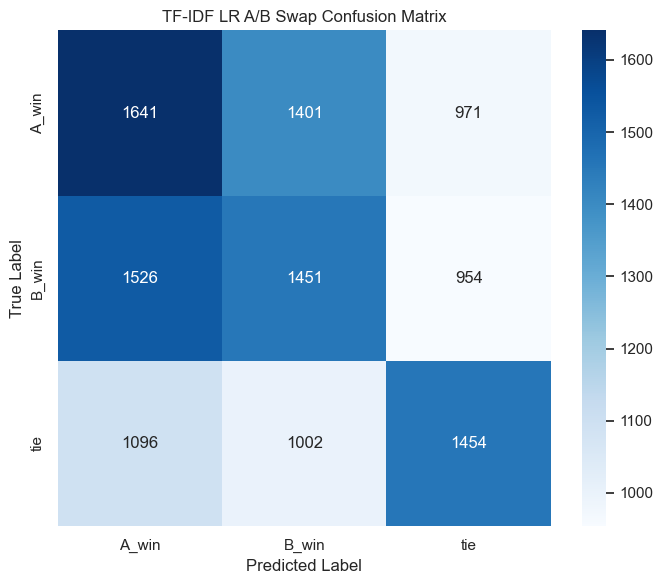

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\tfidf_lr_ab_swap_confusion_matrix.png


In [9]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=TARGET_NAMES,
    yticklabels=TARGET_NAMES,
)
plt.title('TF-IDF LR A/B Swap Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

confusion_matrix_path = figures_dir / 'tfidf_lr_ab_swap_confusion_matrix.png'
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

print(f'Saved figure: {confusion_matrix_path}')

## 10. Save Validation Predictions

Save validation predictions for error analysis and report tables.

In [10]:
valid_predictions = valid_split.copy()
valid_predictions['pred_label'] = valid_pred
valid_predictions['pred_label_name'] = valid_predictions['pred_label'].map(LABEL_NAME_MAP)
valid_predictions['prob_A_win'] = valid_prob[:, 0]
valid_predictions['prob_B_win'] = valid_prob[:, 1]
valid_predictions['prob_tie'] = valid_prob[:, 2]

valid_prediction_columns = [
    'id',
    'label',
    'label_name',
    'pred_label',
    'pred_label_name',
    'prob_A_win',
    'prob_B_win',
    'prob_tie',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
]

valid_predictions_path = oof_dir / 'tfidf_lr_ab_swap_valid_predictions.csv'
valid_predictions[valid_prediction_columns].to_csv(valid_predictions_path, index=False, encoding='utf-8-sig')

print(f'Saved validation predictions: {valid_predictions_path}')
display(valid_predictions[valid_prediction_columns].head())

Saved validation predictions: D:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_ab_swap_valid_predictions.csv


,id,label,label_name,pred_label,pred_label_name,prob_A_win,prob_B_win,prob_tie,prompt_clean,response_a_clean,response_b_clean,response_a_char_len,response_b_char_len,response_len_diff
0,2098233919,0,A_win,1,B_win,0.358578,0.360242,0.281180,"How many tires would you estimate are in the city of Detroit, Michigan? Answer in no more than 3 sentences with your reason.\nWhat about the fact that cars ...","I estimate there are over 1 million tires in the city of Detroit, Michigan. As a major metropolitan area, Detroit has hundreds of thousands of registered ve...","It is difficult to provide an exact estimate without specific data, but we can make a rough estimation. Considering the population of Detroit and assuming a...",795,833,-38
1,2789033728,1,B_win,1,B_win,0.357878,0.358176,0.283946,Write KPI objectives and KPI strategies for Move all companies ISO processes to new ERP,Here are some sample KPI objectives and strategies for moving all company ISO processes to a new ERP system:\n\nKPI Objectives:\n- Complete data migration f...,KPI Objectives:\n1. Successfully migrate all companies' ISO processes to the new ERP system.\n2. Minimize disruption to business operations during the migra...,1504,1599,-95
2,4198930172,2,tie,0,A_win,0.355366,0.354856,0.289778,Name all the skills of Disco Elysium and format your answer as follows:\nName of skill - Relative rating of usefulness from 0 to 100 - Relative rating of in...,Skills of Disco Elysium:\n\n1. Persuasion - 80\/100 - 80\/100\n2. Intimidation - 80\/100 - 80\/100\n3. Investigation - 80\/100 - 80\/100\n4. Stealth...,"Sure, here are the skills in Disco Elysium, along with their relative ratings of usefulness and interestingness:\n\n1. Intelligence - 90% usefulness, 50% in...",1019,1340,-321
3,2396441388,1,B_win,1,B_win,0.352141,0.352479,0.295380,how do you do patch a hole in drywall?,"Patching a hole in drywall involves a few steps. Here's a general guide:\n\n1. Gather materials: You will need a piece of drywall, drywall mud or joint comp...","Patching a hole in drywall involves several steps, including gathering the necessary tools and materials, preparing the area around the hole, applying a pat...",1644,2188,-544
4,3592485435,2,tie,0,A_win,0.338684,0.338558,0.322758,"John places his slice of pie in the refrigerator shared by his coworkers, then goes into his office and closes the door. He cannot see the refrigerator. Sus...","The refrigerator cannot communicate with John directly. However, if John notices that his slice of pie is missing, he might conclude that it has been eaten ...",The refrigerator does not have the ability to communicate or tell John anything. It is an inanimate object. John may notice that his pie is missing when he ...,319,171,148


## 11. Predict Test and Save Submission

Predict test probabilities in original A/B order and save a Kaggle-format submission.

In [11]:
X_test_tfidf = vectorizer.transform(test['text_input'])
test_prob_raw = model.predict_proba(X_test_tfidf)
test_prob = align_probabilities(test_prob_raw, model.classes_, LABELS)

submission = pd.DataFrame({
    'id': test['id'],
    'winner_model_a': test_prob[:, 0],
    'winner_model_b': test_prob[:, 1],
    'winner_tie': test_prob[:, 2],
})

submission_path = submissions_dir / 'tfidf_lr_ab_swap_submission.csv'
submission.to_csv(submission_path, index=False, encoding='utf-8-sig')

print(f'Saved submission: {submission_path}')
print(f'submission shape: {submission.shape}')
display(submission.head())

Saved submission: D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_ab_swap_submission.csv
submission shape: (3, 4)


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.246430,0.244799,0.508771
1,211333,0.350717,0.349165,0.300117
2,1233961,0.394051,0.393645,0.212304


## 12. Swap-Test Averaging Submission

Predict original test order and swapped test order, map swapped probabilities back to original A/B order, then average probabilities.

In [12]:
test_swapped = swap_ab_dataframe(test.copy())
test_swapped['text_input'] = build_text_input(test_swapped)

X_test_swapped_tfidf = vectorizer.transform(test_swapped['text_input'])
test_swapped_prob_raw = model.predict_proba(X_test_swapped_tfidf)
test_swapped_prob = align_probabilities(test_swapped_prob_raw, model.classes_, LABELS)

mapped_test_swapped_prob = np.column_stack([
    test_swapped_prob[:, 1],
    test_swapped_prob[:, 0],
    test_swapped_prob[:, 2],
])

final_test_prob = 0.5 * test_prob + 0.5 * mapped_test_swapped_prob

avg_submission = pd.DataFrame({
    'id': test['id'],
    'winner_model_a': final_test_prob[:, 0],
    'winner_model_b': final_test_prob[:, 1],
    'winner_tie': final_test_prob[:, 2],
})

avg_submission_path = submissions_dir / 'tfidf_lr_ab_swap_avg_submission.csv'
avg_submission.to_csv(avg_submission_path, index=False, encoding='utf-8-sig')

print(f'Saved swap-test averaged submission: {avg_submission_path}')
print(f'avg_submission shape: {avg_submission.shape}')
display(avg_submission.head())

Saved swap-test averaged submission: D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_ab_swap_avg_submission.csv
avg_submission shape: (3, 4)


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.245615,0.245615,0.508771
1,211333,0.350535,0.349804,0.299661
2,1233961,0.393848,0.393848,0.212304


## 13. Save Model Artifacts

Save the fitted TF-IDF vectorizer and Logistic Regression model.

In [13]:
vectorizer_path = models_dir / 'tfidf_ab_swap_vectorizer.joblib'
model_path = models_dir / 'tfidf_ab_swap_logistic_regression.joblib'

joblib.dump(vectorizer, vectorizer_path)
joblib.dump(model, model_path)

print(f'Saved vectorizer: {vectorizer_path}')
print(f'Saved model: {model_path}')

Saved vectorizer: D:\LLM_Classification_finetuning\outputs\models\tfidf_ab_swap_vectorizer.joblib
Saved model: D:\LLM_Classification_finetuning\outputs\models\tfidf_ab_swap_logistic_regression.joblib


## 14. Save Experiment Result

Append the A/B swap experiment result to `experiment_results.csv`.

In [14]:
experiment_result = pd.DataFrame([
    {
        'model_name': 'tfidf_logistic_regression_ab_swap',
        'valid_log_loss': valid_log_loss,
        'valid_accuracy': valid_accuracy,
        'valid_macro_f1': valid_macro_f1,
        'max_features': 100000,
        'ngram_range': '(1, 2)',
        'C': 0.1,
        'random_state': RANDOM_STATE,
        'notes': 'TF-IDF Logistic Regression with A/B swap augmentation. Validation set not augmented. Swap-test averaging submission also saved.',
        'train_rows_original': len(train_split),
        'train_rows_augmented': len(train_aug),
        'valid_rows': len(valid_split),
    }
])

experiment_results_path = logs_dir / 'experiment_results.csv'

if experiment_results_path.exists():
    previous_results = pd.read_csv(experiment_results_path, encoding='utf-8-sig')
    experiment_results = pd.concat([previous_results, experiment_result], ignore_index=True)
else:
    experiment_results = experiment_result

experiment_results.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')

print(f'Saved experiment results: {experiment_results_path}')
display(experiment_results.tail())

Saved experiment results: D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv


,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes,model_checkpoint,max_length,train_rows,valid_rows,train_batch_size,eval_batch_size,gradient_accumulation_steps,train_rows_original,train_rows_augmented
2,tfidf_logistic_regression_tuned,1.080877,0.385264,0.383576,100000.0,"(1, 2)",0.1,42,"tuned C, max_features and ngram_range",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,distilbert_debug,1.078858,0.388889,0.376489,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN
4,distilbert_debug,1.078755,0.392222,0.379731,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN
5,distilbert_medium,1.086948,0.371944,0.371848,NaN,NaN,NaN,42,"DistilBERT finetuning on at most 6000 samples per class, max_length=384.",distilbert-base-uncased,384.0,14400.0,3600.0,8.0,16.0,1.0,NaN,NaN
6,tfidf_logistic_regression_ab_swap,1.078106,0.395442,0.396300,100000.0,"(1, 2)",0.1,42,TF-IDF Logistic Regression with A/B swap augmentation. Validation set not augmented. Swap-test averaging submission also saved.,NaN,NaN,NaN,11496.0,NaN,NaN,NaN,45981.0,91962.0


## 15. Final Checks

Print final metrics, submission checks, and recent experiment log rows.

In [15]:
probability_columns = ['winner_model_a', 'winner_model_b', 'winner_tie']
submission_probability_sum = submission[probability_columns].sum(axis=1)
avg_submission_probability_sum = avg_submission[probability_columns].sum(axis=1)

print(f'valid_log_loss: {valid_log_loss:.6f}')
print(f'valid_accuracy: {valid_accuracy:.6f}')
print(f'valid_macro_f1: {valid_macro_f1:.6f}')
print(f'submission shape: {submission.shape}')
print(f'submission probability sums close to 1: {np.allclose(submission_probability_sum, 1.0, atol=1e-6)}')
print(f'submission has NaN: {submission.isna().any().any()}')
print(f'avg submission shape: {avg_submission.shape}')
print(f'avg submission probability sums close to 1: {np.allclose(avg_submission_probability_sum, 1.0, atol=1e-6)}')
print(f'avg submission has NaN: {avg_submission.isna().any().any()}')

print('\nSaved files:')
for path in [
    confusion_matrix_path,
    valid_predictions_path,
    submission_path,
    avg_submission_path,
    vectorizer_path,
    model_path,
    experiment_results_path,
]:
    print(f'{path.exists()} -> {path}')

print('\nexperiment_results.csv tail:')
display(pd.read_csv(experiment_results_path, encoding='utf-8-sig').tail())

print('TF-IDF A/B swap experiment finished successfully.')

valid_log_loss: 1.078106
valid_accuracy: 0.395442
valid_macro_f1: 0.396300
submission shape: (3, 4)
submission probability sums close to 1: True
submission has NaN: False
avg submission shape: (3, 4)
avg submission probability sums close to 1: True
avg submission has NaN: False

Saved files:
True -> D:\LLM_Classification_finetuning\outputs\figures\tfidf_lr_ab_swap_confusion_matrix.png
True -> D:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_ab_swap_valid_predictions.csv
True -> D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_ab_swap_submission.csv
True -> D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_ab_swap_avg_submission.csv
True -> D:\LLM_Classification_finetuning\outputs\models\tfidf_ab_swap_vectorizer.joblib
True -> D:\LLM_Classification_finetuning\outputs\models\tfidf_ab_swap_logistic_regression.joblib
True -> D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv

experiment_results.csv tail:


,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes,model_checkpoint,max_length,train_rows,valid_rows,train_batch_size,eval_batch_size,gradient_accumulation_steps,train_rows_original,train_rows_augmented
2,tfidf_logistic_regression_tuned,1.080877,0.385264,0.383576,100000.0,"(1, 2)",0.1,42,"tuned C, max_features and ngram_range",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,distilbert_debug,1.078858,0.388889,0.376489,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN
4,distilbert_debug,1.078755,0.392222,0.379731,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN
5,distilbert_medium,1.086948,0.371944,0.371848,NaN,NaN,NaN,42,"DistilBERT finetuning on at most 6000 samples per class, max_length=384.",distilbert-base-uncased,384.0,14400.0,3600.0,8.0,16.0,1.0,NaN,NaN
6,tfidf_logistic_regression_ab_swap,1.078106,0.395442,0.396300,100000.0,"(1, 2)",0.1,42,TF-IDF Logistic Regression with A/B swap augmentation. Validation set not augmented. Swap-test averaging submission also saved.,NaN,NaN,NaN,11496.0,NaN,NaN,NaN,45981.0,91962.0


TF-IDF A/B swap experiment finished successfully.


In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

results = pd.read_csv(ROOT / "outputs" / "logs" / "experiment_results.csv", encoding="utf-8-sig")

cols = ["model_name", "valid_log_loss", "valid_accuracy", "valid_macro_f1", "notes"]
display(results[cols].tail(10))

,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,notes
0,tfidf_logistic_regression,1.139320,0.380219,0.380760,"TF-IDF on prompt_clean, response_a_clean, and ..."
1,tfidf_logistic_regression,1.139320,0.380219,0.380760,"TF-IDF on prompt_clean, response_a_clean, and ..."
2,tfidf_logistic_regression_tuned,1.080877,0.385264,0.383576,"tuned C, max_features and ngram_range"
3,distilbert_debug,1.078858,0.388889,0.376489,DistilBERT debug finetuning on at most 1500 sa...
4,distilbert_debug,1.078755,0.392222,0.379731,DistilBERT debug finetuning on at most 1500 sa...
5,distilbert_medium,1.086948,0.371944,0.371848,DistilBERT finetuning on at most 6000 samples ...
6,tfidf_logistic_regression_ab_swap,1.078106,0.395442,0.396300,TF-IDF Logistic Regression with A/B swap augme...
